<a href="https://colab.research.google.com/github/golam-sakaline/heuristic_search_methods/blob/main/ISE_571_Assignment_1_202523070.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part-II Coding Exercises

**Student Name:** Golam Sakaline  
**Student ID:**  202523070
**Course:** Heuristic Search Methods
**Date:** 26th September, 2026  


### Global Airport Infrastructure: Spatial Patterns and Logistics Insights

Geospatial data is any data related to or containing information about a specific location on the Earth’s surface.This Notebook contains the Second Part of the Assignment-1 which has 4 Questions.

The dataset is obtained from Hugging Face:

- Dataset: `ronnieaban/world-airports`
- URL: https://huggingface.co/datasets/ronnieaban/world-airports


The analysis includes:
1. Spatial-data selection, inspection, cleaning, and conversion to a GeoDataFrame.
2. Data Visualization
3. Picking two points in the Map
4. Applying Routing Algorithms and Comparison


Installationa and Imnporting Libraries

In [1]:
%%capture

!pip -q install datasets geopandas folium plotly pycountry pycountry-convert h3 branca

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import plotly.express as px
import folium
import h3
import pycountry
import pycountry_convert as pc

from datasets import load_dataset
from folium.plugins import HeatMap, FastMarkerCluster
from branca.colormap import linear
from shapely.affinity import scale as scale_geometry
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

RANDOM_SEED = 42

## Problem 1: Selecting and examining a spatial dataset

The World Airports dataset is appropriate for logistics and transportation analysis
because airports are geographically distributed facilities that connect cities,
countries, supply chains, and passenger networks.

The dataset already contains geographic coordinates. Therefore, geocoding addresses
is not required.

For a more consistent comparison, the analysis concentrates on the following
fixed-wing airport categories:

- Small airports
- Medium airports
- Large airports

Closed airports, heliports, balloon ports, and seaplane bases are excluded from the
main analysis.

In [3]:
DATASET_ID = "ronnieaban/world-airports"

airport_dataset = load_dataset(
    DATASET_ID,
    split="train"
)

df_raw = airport_dataset.to_pandas()

print(f"Original number of records: {len(df_raw):,}")
print(f"Number of columns: {df_raw.shape[1]}")

display(df_raw.head())

README.md:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

airport-codes.csv:   0%|          | 0.00/8.37M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/82004 [00:00<?, ? examples/s]

Original number of records: 82,004
Number of columns: 12


,ident,type,name,elevation_ft,continent,iso_country,iso_region,municipality,gps_code,iata_code,local_code,coordinates
0,00A,heliport,Total RF Heliport,11.00,None,US,US-PA,Bensalem,K00A,None,00A,"40.070985, -74.933689"
1,00AA,small_airport,Aero B Ranch Airport,"3,435.00",None,US,US-KS,Leoti,00AA,None,00AA,"38.704022, -101.473911"
2,00AK,small_airport,Lowell Field,450.00,None,US,US-AK,Anchor Point,00AK,None,00AK,"59.947733, -151.692524"
3,00AL,small_airport,Epps Airpark,820.00,None,US,US-AL,Harvest,00AL,None,00AL,"34.86479949951172, -86.77030181884766"
4,00AN,small_airport,Katmai Lodge Airport,80.00,None,US,US-AK,King Salmon,00AN,None,00AN,"59.093287, -156.456699"


In [4]:
print("Column names:")
print(df_raw.columns.tolist())

print("\nDataset information:")
df_raw.info()

missing_summary = (
    df_raw.isna()
    .sum()
    .to_frame("missing_values")
    .assign(missing_percentage=lambda x: 100 * x["missing_values"] / len(df_raw))
    .sort_values("missing_percentage", ascending=False)
)

display(missing_summary)

Column names:
['ident', 'type', 'name', 'elevation_ft', 'continent', 'iso_country', 'iso_region', 'municipality', 'gps_code', 'iata_code', 'local_code', 'coordinates']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82004 entries, 0 to 82003
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ident         82004 non-null  object 
 1   type          82004 non-null  object 
 2   name          82004 non-null  object 
 3   elevation_ft  67503 non-null  float64
 4   continent     43125 non-null  object 
 5   iso_country   81744 non-null  object 
 6   iso_region    82004 non-null  object 
 7   municipality  77170 non-null  object 
 8   gps_code      43041 non-null  object 
 9   iata_code     9103 non-null   object 
 10  local_code    34592 non-null  object 
 11  coordinates   82004 non-null  object 
dtypes: float64(1), object(11)
memory usage: 7.5+ MB


,missing_values,missing_percentage
iata_code,72901,88.90
local_code,47412,57.82
gps_code,38963,47.51
continent,38879,47.41
elevation_ft,14501,17.68
municipality,4834,5.89
iso_country,260,0.32
ident,0,0.00
name,0,0.00
type,0,0.00


In [5]:
df = df_raw.copy()

# The coordinates column is stored as "latitude, longitude".
coordinate_parts = (
    df["coordinates"]
    .astype("string")
    .str.split(",", n=1, expand=True)
)

df["latitude"] = pd.to_numeric(
    coordinate_parts[0].str.strip(),
    errors="coerce"
)

df["longitude"] = pd.to_numeric(
    coordinate_parts[1].str.strip(),
    errors="coerce"
)

df["elevation_ft"] = pd.to_numeric(
    df["elevation_ft"],
    errors="coerce"
)

# Remove records with missing or impossible coordinates.
df = df[
    df["latitude"].between(-90, 90)
    & df["longitude"].between(-180, 180)
].copy()

# Remove duplicated airport identifiers.
df = df.drop_duplicates(subset="ident").copy()

# Keep the airport categories most relevant to air-transport networks.
selected_types = [
    "small_airport",
    "medium_airport",
    "large_airport"
]

airports = df[df["type"].isin(selected_types)].copy()

print(f"Records after coordinate cleaning: {len(df):,}")
print(f"Selected fixed-wing airports: {len(airports):,}")

display(
    airports[
        [
            "ident",
            "name",
            "type",
            "municipality",
            "iso_country",
            "latitude",
            "longitude",
            "elevation_ft"
        ]
    ].head(10)
)

Records after coordinate cleaning: 82,004
Selected fixed-wing airports: 47,118


,ident,name,type,municipality,iso_country,latitude,longitude,elevation_ft
1,00AA,Aero B Ranch Airport,small_airport,Leoti,US,38.70,-101.47,"3,435.00"
2,00AK,Lowell Field,small_airport,Anchor Point,US,59.95,-151.69,450.00
3,00AL,Epps Airpark,small_airport,Harvest,US,34.86,-86.77,820.00
4,00AN,Katmai Lodge Airport,small_airport,King Salmon,US,59.09,-156.46,80.00
6,00AS,Fulton Airport,small_airport,Alex,US,34.94,-97.82,"1,100.00"
7,00AZ,Cordes Airport,small_airport,Cordes,US,34.31,-112.17,"3,810.00"
8,00CA,Goldstone (GTS) Airport,small_airport,Barstow,US,35.35,-116.89,"3,038.00"
9,00CL,Williams Ag Airport,small_airport,Biggs,US,39.43,-121.76,87.00
12,00FA,Grass Patch Airport,small_airport,Bushnell,US,28.65,-82.22,53.00
14,00FL,River Oak Airport,small_airport,Okeechobee,US,27.23,-80.97,35.00


In [6]:
SPECIAL_COUNTRIES = {
    "XK": {
        "alpha3": "XKX",
        "name": "Kosovo",
        "continent": "Europe"
    }
}

CONTINENT_NAMES = {
    "AF": "Africa",
    "AS": "Asia",
    "EU": "Europe",
    "NA": "North America",
    "OC": "Oceania",
    "SA": "South America",
    "AN": "Antarctica"
}

def alpha2_to_alpha3(code):
    """Convert a two-letter country code into a three-letter code."""
    if pd.isna(code):
        return None

    code = str(code).strip().upper()

    if code in SPECIAL_COUNTRIES:
        return SPECIAL_COUNTRIES[code]["alpha3"]

    country = pycountry.countries.get(alpha_2=code)
    return country.alpha_3 if country else None


def country_name(code):
    """Return a readable country name."""
    if pd.isna(code):
        return "Unknown"

    code = str(code).strip().upper()

    if code in SPECIAL_COUNTRIES:
        return SPECIAL_COUNTRIES[code]["name"]

    country = pycountry.countries.get(alpha_2=code)
    return country.name if country else code


def continent_name(code):
    """Infer the continent from the two-letter country code."""
    if pd.isna(code):
        return "Unknown"

    code = str(code).strip().upper()

    if code in SPECIAL_COUNTRIES:
        return SPECIAL_COUNTRIES[code]["continent"]

    try:
        continent_code = pc.country_alpha2_to_continent_code(code)
        return CONTINENT_NAMES.get(continent_code, "Unknown")
    except (KeyError, ValueError):
        return "Unknown"


airports["iso_alpha3"] = airports["iso_country"].apply(alpha2_to_alpha3)
airports["country_name"] = airports["iso_country"].apply(country_name)
airports["continent_name"] = airports["iso_country"].apply(continent_name)

display(
    airports[
        [
            "name",
            "iso_country",
            "iso_alpha3",
            "country_name",
            "continent_name"
        ]
    ].head()
)

,name,iso_country,iso_alpha3,country_name,continent_name
1,Aero B Ranch Airport,US,USA,United States,North America
2,Lowell Field,US,USA,United States,North America
3,Epps Airpark,US,USA,United States,North America
4,Katmai Lodge Airport,US,USA,United States,North America
6,Fulton Airport,US,USA,United States,North America


In [7]:
airports_gdf = gpd.GeoDataFrame(
    airports,
    geometry=gpd.points_from_xy(
        airports["longitude"],
        airports["latitude"]
    ),
    crs="EPSG:4326"
)

print("Coordinate Reference System:", airports_gdf.crs)
print("Geometry type:", airports_gdf.geometry.geom_type.unique())
print(f"Number of spatial records: {len(airports_gdf):,}")

display(airports_gdf.head())

Coordinate Reference System: EPSG:4326
Geometry type: ['Point']
Number of spatial records: 47,118


,ident,type,name,elevation_ft,continent,iso_country,iso_region,municipality,gps_code,iata_code,local_code,coordinates,latitude,longitude,iso_alpha3,country_name,continent_name,geometry
1,00AA,small_airport,Aero B Ranch Airport,"3,435.00",None,US,US-KS,Leoti,00AA,None,00AA,"38.704022, -101.473911",38.70,-101.47,USA,United States,North America,POINT (-101.47391 38.70402)
2,00AK,small_airport,Lowell Field,450.00,None,US,US-AK,Anchor Point,00AK,None,00AK,"59.947733, -151.692524",59.95,-151.69,USA,United States,North America,POINT (-151.69252 59.94773)
3,00AL,small_airport,Epps Airpark,820.00,None,US,US-AL,Harvest,00AL,None,00AL,"34.86479949951172, -86.77030181884766",34.86,-86.77,USA,United States,North America,POINT (-86.7703 34.8648)
4,00AN,small_airport,Katmai Lodge Airport,80.00,None,US,US-AK,King Salmon,00AN,None,00AN,"59.093287, -156.456699",59.09,-156.46,USA,United States,North America,POINT (-156.4567 59.09329)
6,00AS,small_airport,Fulton Airport,"1,100.00",None,US,US-OK,Alex,00AS,None,00AS,"34.9428028, -97.8180194",34.94,-97.82,USA,United States,North America,POINT (-97.81802 34.9428)


In [8]:
quality_summary = pd.DataFrame(
    {
        "measure": [
            "Original records",
            "Valid-coordinate records",
            "Selected fixed-wing airports",
            "Countries represented",
            "Records with IATA codes",
            "Records with elevation information"
        ],
        "value": [
            len(df_raw),
            len(df),
            len(airports_gdf),
            airports_gdf["iso_country"].nunique(),
            airports_gdf["iata_code"].fillna("").str.strip().ne("").sum(),
            airports_gdf["elevation_ft"].notna().sum()
        ]
    }
)

display(quality_summary)

print("\nSelected airports by type:")
display(
    airports_gdf["type"]
    .value_counts()
    .rename_axis("airport_type")
    .reset_index(name="number_of_airports")
)

,measure,value
0,Original records,82004
1,Valid-coordinate records,82004
2,Selected fixed-wing airports,47118
3,Countries represented,238
4,Records with IATA codes,8855
5,Records with elevation information,41971



Selected airports by type:


,airport_type,number_of_airports
0,small_airport,41945
1,medium_airport,4696
2,large_airport,477


In [9]:
country_statistics = (
    airports_gdf
    .groupby(
        [
            "iso_country",
            "iso_alpha3",
            "country_name",
            "continent_name"
        ],
        dropna=False,
        as_index=False
    )
    .agg(
        airport_count=("ident", "size"),
        latitude=("latitude", "mean"),
        longitude=("longitude", "mean"),
        mean_elevation_ft=("elevation_ft", "mean")
    )
)

country_statistics["log_airport_count"] = np.log1p(
    country_statistics["airport_count"]
)

country_statistics = country_statistics.sort_values(
    "airport_count",
    ascending=False
)

print("Top 15 countries by the number of selected airports:")

display(
    country_statistics[
        [
            "country_name",
            "continent_name",
            "airport_count",
            "mean_elevation_ft"
        ]
    ].head(15)
)

Top 15 countries by the number of selected airports:


,country_name,continent_name,airport_count,mean_elevation_ft
221,United States,North America,16123,"1,350.72"
28,Brazil,South America,5251,"1,297.05"
11,Australia,Oceania,2209,603.04
149,Mexico,North America,1579,"2,216.13"
34,Canada,North America,1449,"1,281.09"
71,France,Europe,1189,"1,143.97"
73,United Kingdom,Europe,1052,249.80
181,Russian Federation,Europe,904,562.12
53,Germany,Europe,840,922.00
8,Argentina,South America,757,826.68


## Problem 2: Spatial-data visualization

The maps below answer different types of spatial questions:

- **Choropleth:** Which countries contain the largest numbers of airports?
- **Cartogram:** How would the world map change if country size reflected airport count?
- **Bubble map:** How do country-level airport totals compare?
- **Hexagonal binning:** Where are local concentrations of airports?
- **Heat map:** Where are the global airport-density hotspots?
- **Cluster map:** How are individual airport records grouped at different zoom levels?

In [10]:
choropleth_data = country_statistics.dropna(
    subset=["iso_alpha3"]
).copy()

fig_choropleth = px.choropleth(
    choropleth_data,
    locations="iso_alpha3",
    locationmode="ISO-3",
    color="log_airport_count",
    hover_name="country_name",
    hover_data={
        "airport_count": ":,",
        "continent_name": True,
        "mean_elevation_ft": ":.0f",
        "log_airport_count": False,
        "iso_alpha3": False
    },
    color_continuous_scale="YlOrRd",
    projection="natural earth",
    labels={
        "airport_count": "Number of airports",
        "continent_name": "Continent",
        "mean_elevation_ft": "Mean elevation (ft)",
        "log_airport_count": "log(1 + airport count)"
    },
    title="Choropleth Map: Number of Fixed-Wing Airports by Country"
)

fig_choropleth.update_layout(
    height=650,
    margin=dict(l=0, r=0, t=70, b=0)
)

fig_choropleth.show()

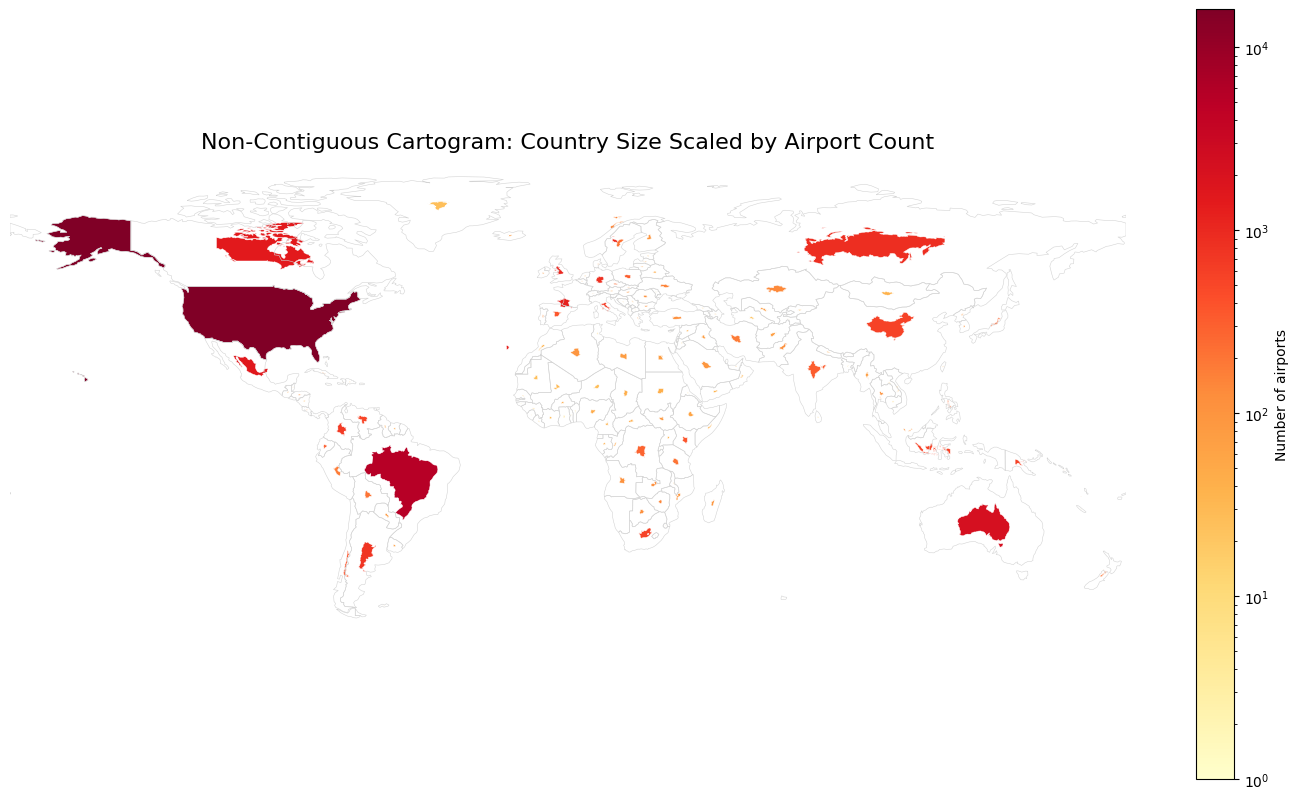

In [11]:
# Natural Earth country boundaries
WORLD_GEOJSON = (
    "https://raw.githubusercontent.com/nvkelso/"
    "natural-earth-vector/master/geojson/"
    "ne_110m_admin_0_countries.geojson"
)

world = gpd.read_file(WORLD_GEOJSON)

# Remove Antarctica to improve the map's visual scale.
if "CONTINENT" in world.columns:
    world = world[world["CONTINENT"] != "Antarctica"].copy()

# Find an appropriate two-letter ISO-code column.
iso_candidates = ["ISO_A2_EH", "ISO_A2", "WB_A2"]
iso_column = next(
    column for column in iso_candidates if column in world.columns
)

world["iso_country"] = world[iso_column].astype(str).str.upper()

country_counts = country_statistics[
    ["iso_country", "airport_count"]
].copy()

cartogram = world.merge(
    country_counts,
    on="iso_country",
    how="left"
)

cartogram["airport_count"] = (
    cartogram["airport_count"]
    .fillna(0)
    .astype(int)
)

maximum_count = cartogram["airport_count"].max()

# Polygon area changes approximately with the square of the scale factor.
# A small minimum scale keeps low-count countries visible.
cartogram["scale_factor"] = (
    0.08
    + 0.92
    * np.sqrt(cartogram["airport_count"] / maximum_count)
)

cartogram_scaled = cartogram.copy()

cartogram_scaled["geometry"] = [
    scale_geometry(
        geometry,
        xfact=factor,
        yfact=factor,
        origin="centroid"
    )
    for geometry, factor in zip(
        cartogram["geometry"],
        cartogram["scale_factor"]
    )
]

fig, ax = plt.subplots(figsize=(18, 10))

# Original country outlines provide geographic reference.
world.boundary.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.4
)

cartogram_scaled[
    cartogram_scaled["airport_count"] > 0
].plot(
    ax=ax,
    column="airport_count",
    cmap="YlOrRd",
    norm=LogNorm(vmin=1, vmax=maximum_count),
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    legend_kwds={"label": "Number of airports"}
)

ax.set_xlim(-180, 180)
ax.set_ylim(-60, 90)
ax.set_title(
    "Non-Contiguous Cartogram: Country Size Scaled by Airport Count",
    fontsize=16
)
ax.set_axis_off()

plt.show()

In [12]:
bubble_data = country_statistics[
    country_statistics["iso_alpha3"].notna()
].copy()

fig_bubble = px.scatter_geo(
    bubble_data,
    lat="latitude",
    lon="longitude",
    size="airport_count",
    color="continent_name",
    hover_name="country_name",
    hover_data={
        "airport_count": ":,",
        "mean_elevation_ft": ":.0f",
        "latitude": False,
        "longitude": False
    },
    size_max=55,
    projection="natural earth",
    labels={
        "airport_count": "Number of airports",
        "continent_name": "Continent",
        "mean_elevation_ft": "Mean elevation (ft)"
    },
    title="Bubble Map: Country-Level Airport Counts"
)

fig_bubble.update_geos(
    showland=True,
    landcolor="rgb(240, 240, 240)",
    showcountries=True,
    countrycolor="white",
    showocean=True,
    oceancolor="rgb(220, 235, 245)"
)

fig_bubble.update_layout(
    height=650,
    margin=dict(l=0, r=0, t=70, b=0)
)

fig_bubble.show()

In [13]:
H3_RESOLUTION = 2

airports_h3 = airports_gdf.copy()

airports_h3["h3_cell"] = [
    h3.latlng_to_cell(latitude, longitude, H3_RESOLUTION)
    for latitude, longitude in zip(
        airports_h3["latitude"],
        airports_h3["longitude"]
    )
]

hex_counts = (
    airports_h3
    .groupby("h3_cell")
    .size()
    .reset_index(name="airport_count")
    .sort_values("airport_count", ascending=False)
)

hex_features = []

for row in hex_counts.itertuples(index=False):
    boundary = h3.cell_to_boundary(row.h3_cell)

    # H3 returns (latitude, longitude); GeoJSON requires (longitude, latitude).
    polygon = [[longitude, latitude] for latitude, longitude in boundary]
    polygon.append(polygon[0])

    hex_features.append(
        {
            "type": "Feature",
            "properties": {
                "h3_cell": row.h3_cell,
                "airport_count": int(row.airport_count)
            },
            "geometry": {
                "type": "Polygon",
                "coordinates": [polygon]
            }
        }
    )

hex_geojson = {
    "type": "FeatureCollection",
    "features": hex_features
}

maximum_hex_count = int(hex_counts["airport_count"].max())

hex_colormap = linear.YlOrRd_09.scale(
    np.log1p(1),
    np.log1p(maximum_hex_count)
)

hex_colormap.caption = "log(1 + number of airports in each H3 cell)"

m_hex = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="Esri.WorldStreetMap",
    min_zoom=2
)

folium.GeoJson(
    hex_geojson,
    name="Airport hexagonal bins",
    style_function=lambda feature: {
        "fillColor": hex_colormap(
            np.log1p(feature["properties"]["airport_count"])
        ),
        "color": "#555555",
        "weight": 0.35,
        "fillOpacity": 0.75
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["h3_cell", "airport_count"],
        aliases=["H3 cell:", "Number of airports:"],
        localize=True
    )
).add_to(m_hex)

hex_colormap.add_to(m_hex)
folium.LayerControl().add_to(m_hex)

title_html = """
<h3 style="position: fixed;
           top: 10px;
           left: 50px;
           z-index: 9999;
           background-color: white;
           padding: 8px;">
    Hexagonal-Bin Map of World Airports
</h3>
"""

m_hex.get_root().html.add_child(folium.Element(title_html))

m_hex

In [14]:
heat_sample_size = min(30_000, len(airports_gdf))

heat_data = airports_gdf.sample(
    n=heat_sample_size,
    random_state=RANDOM_SEED
)

m_heat = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="Esri.WorldStreetMap",
    min_zoom=2
)

HeatMap(
    heat_data[["latitude", "longitude"]].values.tolist(),
    radius=9,
    blur=12,
    min_opacity=0.25,
    max_zoom=7,
    name="Airport density"
).add_to(m_heat)

folium.LayerControl().add_to(m_heat)

title_html = f"""
<h3 style="position: fixed;
           top: 10px;
           left: 50px;
           z-index: 9999;
           color: white;
           background-color: rgba(0,0,0,0.70);
           padding: 8px;">
    Airport-Density Heat Map — {heat_sample_size:,} Sampled Airports
</h3>
"""

m_heat.get_root().html.add_child(folium.Element(title_html))

m_heat

In [15]:
cluster_sample_size = min(30_000, len(airports_gdf))

cluster_data = airports_gdf.sample(
    n=cluster_sample_size,
    random_state=RANDOM_SEED
)

m_cluster = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="Esri.WorldStreetMap",
    min_zoom=2
)

FastMarkerCluster(
    data=cluster_data[["latitude", "longitude"]].values.tolist(),
    name="Airport clusters"
).add_to(m_cluster)

folium.LayerControl().add_to(m_cluster)

title_html = f"""
<h3 style="position: fixed;
           top: 10px;
           left: 50px;
           z-index: 9999;
           background-color: white;
           padding: 8px;">
    Cluster Map — {cluster_sample_size:,} Sampled Airports
</h3>
"""

m_cluster.get_root().html.add_child(folium.Element(title_html))

m_cluster

In [16]:
top_five = country_statistics.nlargest(5, "airport_count")

top_five_text = "; ".join(
    f"{row.country_name}: {row.airport_count:,}"
    for row in top_five.itertuples(index=False)
)

top_five_share = (
    100 * top_five["airport_count"].sum() / len(airports_gdf)
)

continent_counts = (
    airports_gdf
    .groupby("continent_name")
    .size()
    .sort_values(ascending=False)
)

leading_continent = continent_counts.index[0]
leading_continent_count = int(continent_counts.iloc[0])

medium_large_share = (
    100
    * airports_gdf["type"]
    .isin(["medium_airport", "large_airport"])
    .mean()
)

iata_share = (
    100
    * airports_gdf["iata_code"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
    .mean()
)

densest_hex = hex_counts.iloc[0]
dense_latitude, dense_longitude = h3.cell_to_latlng(
    densest_hex["h3_cell"]
)

display(
    Markdown(
        f"""
## Some numerical observations

1. The five countries with the largest registered airport counts are
   **{top_five_text}**.

2. Together, these five countries contain approximately
   **{top_five_share:.1f}%** of the selected airport records.

3. **{leading_continent}** has the largest number of selected airports,
   with **{leading_continent_count:,}** records.

4. Medium and large airports represent approximately
   **{medium_large_share:.1f}%** of the selected airports. Therefore, much
   of the dataset consists of small airports.

5. Approximately **{iata_share:.1f}%** of the selected airports have an
   IATA code. Airport count should therefore not be interpreted as passenger
   traffic or commercial importance.

6. At H3 resolution {H3_RESOLUTION}, the densest hexagonal cell is centered
   near latitude **{dense_latitude:.2f}** and longitude
   **{dense_longitude:.2f}**, and contains **{int(densest_hex["airport_count"]):,}**
   airport records.
"""
    )
)


## Some numerical observations

1. The five countries with the largest registered airport counts are
   **United States: 16,123; Brazil: 5,251; Australia: 2,209; Mexico: 1,579; Canada: 1,449**.

2. Together, these five countries contain approximately
   **56.5%** of the selected airport records.

3. **North America** has the largest number of selected airports,
   with **19,986** records.

4. Medium and large airports represent approximately
   **11.0%** of the selected airports. Therefore, much
   of the dataset consists of small airports.

5. Approximately **18.8%** of the selected airports have an
   IATA code. Airport count should therefore not be interpreted as passenger
   traffic or commercial importance.

6. At H3 resolution 2, the densest hexagonal cell is centered
   near latitude **33.36** and longitude
   **-96.76**, and contains **496**
   airport records.


# Problem 3 and 4: Route Search between KFUPM and LuLu Hypermarket, Al Khobar, Applying Routing Algorithms and Compariosn

## Selected points of interest

1. **Origin:** King Fahd University of Petroleum and Minerals (KFUPM)
2. **Destination:** LuLu Hypermarket, Al Khobar

The following routing algorithms are compared:

1. Breadth-First Search (BFS)
2. Depth-First Search (DFS)
3. Dijkstra's algorithm
4. Hill Climbing
5. A* search
6. Simulated Annealing

In [17]:
%%capture

!pip -q install osmnx

In [18]:
!pip -q install networkx

In [19]:
import math
import time
from collections import deque

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import osmnx as ox

from matplotlib.lines import Line2D

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

ox.settings.use_cache = True
ox.settings.log_console = False
ox.settings.requests_timeout = 180

print("OSMnx version:", ox.__version__)
print("NetworkX version:", nx.__version__)

OSMnx version: 2.1.1
NetworkX version: 3.6.1


In [20]:
# Coordinates are stored as (latitude, longitude).

POIS = {
    "KFUPM": {
        "latitude": 26.3071046,
        "longitude": 50.1459423,
        "description": "King Fahd University of Petroleum and Minerals"
    },
    "LuLu Hypermarket": {
        "latitude": 26.2675309,
        "longitude": 50.2144107,
        "description": "LuLu Hypermarket, 2634 Prince Turkey Street, Al Khobar"
    }
}

origin_coordinates = (
    POIS["KFUPM"]["latitude"],
    POIS["KFUPM"]["longitude"]
)

destination_coordinates = (
    POIS["LuLu Hypermarket"]["latitude"],
    POIS["LuLu Hypermarket"]["longitude"]
)

poi_table = pd.DataFrame(
    [
        {
            "Point": name,
            "Description": information["description"],
            "Latitude": information["latitude"],
            "Longitude": information["longitude"]
        }
        for name, information in POIS.items()
    ]
)

display(poi_table)

,Point,Description,Latitude,Longitude
0,KFUPM,King Fahd University of Petroleum and Minerals,26.31,50.15
1,LuLu Hypermarket,"LuLu Hypermarket, 2634 Prince Turkey Street, A...",26.27,50.21


In [21]:
EARTH_RADIUS_M = 6_371_008.8


def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two coordinates in meters."""

    lat1, lon1, lat2, lon2 = map(
        math.radians,
        [lat1, lon1, lat2, lon2]
    )

    delta_latitude = lat2 - lat1
    delta_longitude = lon2 - lon1

    a = (
        math.sin(delta_latitude / 2) ** 2
        + math.cos(lat1)
        * math.cos(lat2)
        * math.sin(delta_longitude / 2) ** 2
    )

    return (
        2
        * EARTH_RADIUS_M
        * math.asin(math.sqrt(a))
    )


straight_line_distance = haversine_distance(
    origin_coordinates[0],
    origin_coordinates[1],
    destination_coordinates[0],
    destination_coordinates[1]
)

# Midpoint of the two selected locations.
graph_center = (
    (origin_coordinates[0] + destination_coordinates[0]) / 2,
    (origin_coordinates[1] + destination_coordinates[1]) / 2
)

# Half the point-to-point distance plus a generous network buffer.
graph_radius_m = int(straight_line_distance / 2 + 4_000)

print(
    f"Straight-line distance: "
    f"{straight_line_distance:,.2f} meters"
)

print(
    f"Street-network download radius: "
    f"{graph_radius_m:,} meters"
)

Straight-line distance: 8,121.45 meters
Street-network download radius: 8,060 meters


In [22]:
G = ox.graph.graph_from_point(
    center_point=graph_center,
    dist=graph_radius_m,
    dist_type="bbox",
    network_type="drive",
    simplify=True,
    retain_all=False,
    truncate_by_edge=True
)

print(f"Street-network nodes: {G.number_of_nodes():,}")
print(f"Street-network directed edges: {G.number_of_edges():,}")
print("Coordinate reference system:", G.graph["crs"])

Street-network nodes: 12,378
Street-network directed edges: 30,794
Coordinate reference system: epsg:4326


In [23]:
origin_node, origin_snap_distance = ox.distance.nearest_nodes(
    G,
    X=origin_coordinates[1],
    Y=origin_coordinates[0],
    return_dist=True
)

destination_node, destination_snap_distance = ox.distance.nearest_nodes(
    G,
    X=destination_coordinates[1],
    Y=destination_coordinates[0],
    return_dist=True
)

print("Origin node:", origin_node)
print("Destination node:", destination_node)

print(
    f"KFUPM snapping distance: "
    f"{origin_snap_distance:,.2f} meters"
)

print(
    f"LuLu snapping distance: "
    f"{destination_snap_distance:,.2f} meters"
)

Origin node: 6582857339
Destination node: 14181202926
KFUPM snapping distance: 17.03 meters
LuLu snapping distance: 124.57 meters


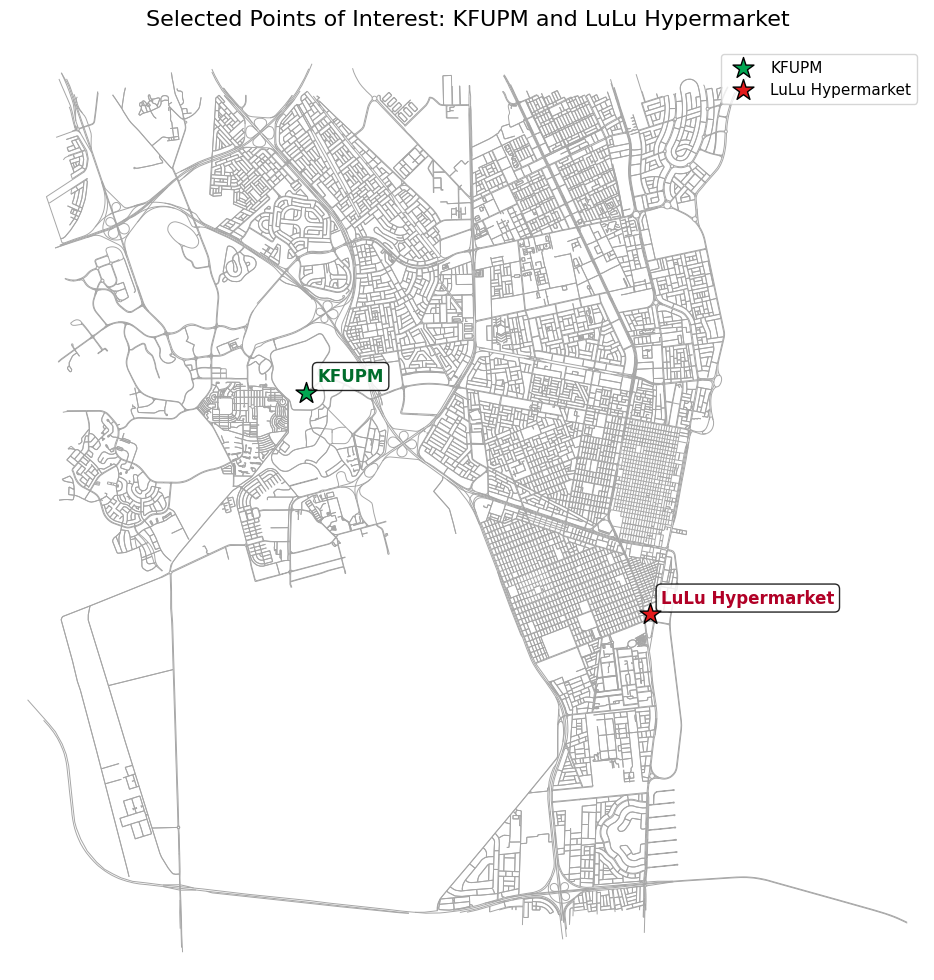

In [24]:
fig, ax = ox.plot.plot_graph(
    G,
    node_size=0,
    edge_color="#A6A6A6",
    edge_linewidth=0.7,
    bgcolor="white",
    show=False,
    close=False,
    figsize=(12, 12)
)

# Original POI markers
ax.scatter(
    POIS["KFUPM"]["longitude"],
    POIS["KFUPM"]["latitude"],
    s=250,
    marker="*",
    color="#00A651",
    edgecolor="black",
    linewidth=1,
    zorder=5,
    label="KFUPM"
)

ax.scatter(
    POIS["LuLu Hypermarket"]["longitude"],
    POIS["LuLu Hypermarket"]["latitude"],
    s=250,
    marker="*",
    color="#E31A1C",
    edgecolor="black",
    linewidth=1,
    zorder=5,
    label="LuLu Hypermarket"
)

ax.annotate(
    "KFUPM",
    xy=(
        POIS["KFUPM"]["longitude"],
        POIS["KFUPM"]["latitude"]
    ),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=12,
    fontweight="bold",
    color="#006D2C",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        alpha=0.85
    )
)

ax.annotate(
    "LuLu Hypermarket",
    xy=(
        POIS["LuLu Hypermarket"]["longitude"],
        POIS["LuLu Hypermarket"]["latitude"]
    ),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=12,
    fontweight="bold",
    color="#B10026",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        alpha=0.85
    )
)

ax.set_title(
    "Selected Points of Interest: KFUPM and LuLu Hypermarket",
    fontsize=16,
    pad=15
)

ax.legend(loc="upper right", fontsize=11)

plt.show()

In [25]:
H = ox.convert.to_digraph(
    G,
    weight="length"
)

print(f"Search-graph nodes: {H.number_of_nodes():,}")
print(f"Search-graph directed edges: {H.number_of_edges():,}")

if not nx.has_path(H, origin_node, destination_node):
    raise nx.NetworkXNoPath(
        "No directed driving route was found. "
        "Increase graph_radius_m and rerun the graph-download cells."
    )

print("A directed route exists between the two selected points.")

Search-graph nodes: 12,378
Search-graph directed edges: 30,496
A directed route exists between the two selected points.


In [26]:
def reconstruct_path(parent, source, target):
    """Reconstruct a source-to-target path from a parent dictionary."""

    if target not in parent:
        raise nx.NetworkXNoPath(
            f"No route exists from node {source} to node {target}."
        )

    path = []
    current = target

    while current is not None:
        path.append(current)
        current = parent[current]

    path.reverse()
    return path


def route_length_m(graph, route):
    """Calculate the total route length in meters."""

    return sum(
        float(graph[u][v]["length"])
        for u, v in zip(route[:-1], route[1:])
    )


def node_heuristic(node, target):
    """Great-circle distance from one graph node to another."""

    node_data = H.nodes[node]
    target_data = H.nodes[target]

    return haversine_distance(
        node_data["y"],
        node_data["x"],
        target_data["y"],
        target_data["x"]
    )


def remove_cycles(path):
    """Remove loops while retaining a valid source-to-target walk."""

    result = []
    node_positions = {}

    for node in path:
        if node in node_positions:
            repeated_position = node_positions[node]

            removed_nodes = result[repeated_position + 1:]

            for removed_node in removed_nodes:
                node_positions.pop(removed_node, None)

            result = result[:repeated_position + 1]

        else:
            node_positions[node] = len(result)
            result.append(node)

    return result

In [27]:
def bfs_route(graph, source, target):
    """
    Breadth-First Search.

    BFS minimizes the number of graph edges, not distance in meters.
    """

    queue = deque([source])
    parent = {source: None}

    while queue:
        current = queue.popleft()

        if current == target:
            return reconstruct_path(
                parent,
                source,
                target
            )

        for neighbor in graph.successors(current):
            if neighbor not in parent:
                parent[neighbor] = current
                queue.append(neighbor)

    raise nx.NetworkXNoPath("BFS could not find a route.")

In [28]:
def dfs_route(graph, source, target):
    """
    Depth-First Search.

    DFS explores one branch as deeply as possible before backtracking.
    It does not guarantee the shortest route.
    """

    stack = [source]
    parent = {source: None}

    while stack:
        current = stack.pop()

        if current == target:
            return reconstruct_path(
                parent,
                source,
                target
            )

        neighbors = list(graph.successors(current))

        # Reverse the order to obtain deterministic stack behaviour.
        for neighbor in reversed(neighbors):
            if neighbor not in parent:
                parent[neighbor] = current
                stack.append(neighbor)

    raise nx.NetworkXNoPath("DFS could not find a route.")

In [29]:
def dijkstra_route(graph, source, target):
    """
    Dijkstra minimizes the sum of road-segment lengths.
    """

    return nx.dijkstra_path(
        graph,
        source=source,
        target=target,
        weight="length"
    )

In [30]:
def hill_climbing_route(graph, source, target):
    """
    Heuristic Hill Climbing with backtracking.

    At every step, the algorithm selects the unvisited successor
    geographically closest to the destination.

    Backtracking is added so the algorithm can recover from dead ends,
    one-way restrictions, and local minima.
    """

    current_path = [source]
    visited = {source}

    while current_path:
        current = current_path[-1]

        if current == target:
            return current_path.copy()

        candidates = [
            neighbor
            for neighbor in graph.successors(current)
            if neighbor not in visited
        ]

        if candidates:
            # Select the successor estimated to be closest to the goal.
            next_node = min(
                candidates,
                key=lambda node: node_heuristic(node, target)
            )

            visited.add(next_node)
            current_path.append(next_node)

        else:
            # No unvisited successor: return to the previous node.
            current_path.pop()

    raise nx.NetworkXNoPath(
        "Hill Climbing could not find a route."
    )

In [31]:
def astar_route(graph, source, target):
    """
    A* minimizes actual distance travelled plus estimated remaining distance.

    The heuristic is straight-line great-circle distance in meters.
    """

    return nx.astar_path(
        graph,
        source=source,
        target=target,
        heuristic=node_heuristic,
        weight="length"
    )

In [32]:
def simulated_annealing_route(
    graph,
    source,
    target,
    iterations=80,
    initial_temperature=None,
    cooling_rate=0.96,
    seed=RANDOM_SEED
):
    """
    Route-level Simulated Annealing.

    1. Begin with a feasible BFS route.
    2. Select two positions along the current route.
    3. Replace the section between them using randomized edge costs.
    4. Accept improvements.
    5. Sometimes accept worse routes depending on temperature.
    6. Return the best route found during the search.
    """

    rng = np.random.default_rng(seed)

    # Initial feasible solution.
    current_route = bfs_route(
        graph,
        source,
        target
    )

    current_cost = route_length_m(
        graph,
        current_route
    )

    best_route = current_route.copy()
    best_cost = current_cost

    if initial_temperature is None:
        initial_temperature = max(
            1.0,
            0.05 * current_cost
        )

    temperature = initial_temperature
    edge_list = list(graph.edges())

    for iteration in range(iterations):
        if len(current_route) < 4:
            break

        # Select two non-adjacent positions.
        first_index = int(
            rng.integers(0, len(current_route) - 2)
        )

        second_index = int(
            rng.integers(
                first_index + 2,
                len(current_route)
            )
        )

        section_start = current_route[first_index]
        section_end = current_route[second_index]

        # Randomly perturb edge costs to generate an alternative section.
        random_multipliers = rng.lognormal(
            mean=0.0,
            sigma=0.45,
            size=len(edge_list)
        )

        noisy_costs = {
            edge: multiplier
            for edge, multiplier in zip(
                edge_list,
                random_multipliers
            )
        }

        def randomized_edge_cost(u, v, edge_data):
            return (
                float(edge_data["length"])
                * noisy_costs[(u, v)]
            )

        try:
            alternative_section = nx.dijkstra_path(
                graph,
                source=section_start,
                target=section_end,
                weight=randomized_edge_cost
            )
        except nx.NetworkXNoPath:
            temperature *= cooling_rate
            continue

        candidate_route = (
            current_route[:first_index]
            + alternative_section
            + current_route[second_index + 1:]
        )

        candidate_route = remove_cycles(candidate_route)

        if (
            candidate_route[0] != source
            or candidate_route[-1] != target
        ):
            temperature *= cooling_rate
            continue

        candidate_cost = route_length_m(
            graph,
            candidate_route
        )

        cost_change = candidate_cost - current_cost

        accept_candidate = (
            cost_change <= 0
            or rng.random()
            < math.exp(
                -cost_change / max(temperature, 1e-12)
            )
        )

        if accept_candidate:
            current_route = candidate_route
            current_cost = candidate_cost

        if current_cost < best_cost:
            best_route = current_route.copy()
            best_cost = current_cost

        temperature *= cooling_rate

    return best_route

In [33]:
algorithm_functions = {
    "BFS": lambda: bfs_route(
        H,
        origin_node,
        destination_node
    ),

    "DFS": lambda: dfs_route(
        H,
        origin_node,
        destination_node
    ),

    "Dijkstra": lambda: dijkstra_route(
        H,
        origin_node,
        destination_node
    ),

    "Hill Climbing": lambda: hill_climbing_route(
        H,
        origin_node,
        destination_node
    ),

    "A*": lambda: astar_route(
        H,
        origin_node,
        destination_node
    ),

    "Simulated Annealing": lambda: simulated_annealing_route(
        H,
        origin_node,
        destination_node,
        iterations=80,
        seed=RANDOM_SEED
    )
}

routes = {}
results = []

for algorithm_name, algorithm_function in algorithm_functions.items():
    start_time = time.perf_counter()

    try:
        route = algorithm_function()

        elapsed_time_ms = (
            time.perf_counter() - start_time
        ) * 1_000

        length_m = route_length_m(H, route)

        routes[algorithm_name] = route

        results.append(
            {
                "Algorithm": algorithm_name,
                "Status": "Route found",
                "Time (ms)": elapsed_time_ms,
                "Route length (m)": length_m,
                "Route length (km)": length_m / 1_000,
                "Nodes in route": len(route)
            }
        )

    except nx.NetworkXNoPath:
        elapsed_time_ms = (
            time.perf_counter() - start_time
        ) * 1_000

        results.append(
            {
                "Algorithm": algorithm_name,
                "Status": "No route",
                "Time (ms)": elapsed_time_ms,
                "Route length (m)": np.nan,
                "Route length (km)": np.nan,
                "Nodes in route": np.nan
            }
        )

comparison = pd.DataFrame(results)

# Use Dijkstra as the optimal-distance benchmark.
dijkstra_length = comparison.loc[
    comparison["Algorithm"] == "Dijkstra",
    "Route length (m)"
].iloc[0]

comparison["Distance gap from Dijkstra (%)"] = (
    100
    * (
        comparison["Route length (m)"]
        - dijkstra_length
    )
    / dijkstra_length
)

display(
    comparison.style.format(
        {
            "Time (ms)": "{:,.3f}",
            "Route length (m)": "{:,.2f}",
            "Route length (km)": "{:,.3f}",
            "Nodes in route": "{:,.0f}",
            "Distance gap from Dijkstra (%)": "{:,.2f}%"
        },
        na_rep="N/A"
    )
)

,Algorithm,Status,Time (ms),Route length (m),Route length (km),Nodes in route,Distance gap from Dijkstra (%)
0,BFS,Route found,8.547,"9,966.01",9.966,44,2.21%
1,DFS,Route found,3.162,"69,191.64",69.192,672,609.61%
2,Dijkstra,Route found,71.405,"9,750.67",9.751,85,0.00%
3,Hill Climbing,Route found,1.495,"50,635.77",50.636,222,419.31%
4,A*,Route found,12.526,"9,750.67",9.751,85,0.00%
5,Simulated Annealing,Route found,"1,580.390","9,797.01",9.797,72,0.48%


In [34]:
def validate_route(graph, route, source, target):
    """Check endpoints and ensure every consecutive pair has an edge."""

    correct_endpoints = (
        route[0] == source
        and route[-1] == target
    )

    valid_edges = all(
        graph.has_edge(u, v)
        for u, v in zip(route[:-1], route[1:])
    )

    return correct_endpoints and valid_edges


validation_results = pd.DataFrame(
    {
        "Algorithm": list(routes.keys()),
        "Valid directed route": [
            validate_route(
                H,
                route,
                origin_node,
                destination_node
            )
            for route in routes.values()
        ]
    }
)

display(validation_results)

,Algorithm,Valid directed route
0,BFS,True
1,DFS,True
2,Dijkstra,True
3,Hill Climbing,True
4,A*,True
5,Simulated Annealing,True


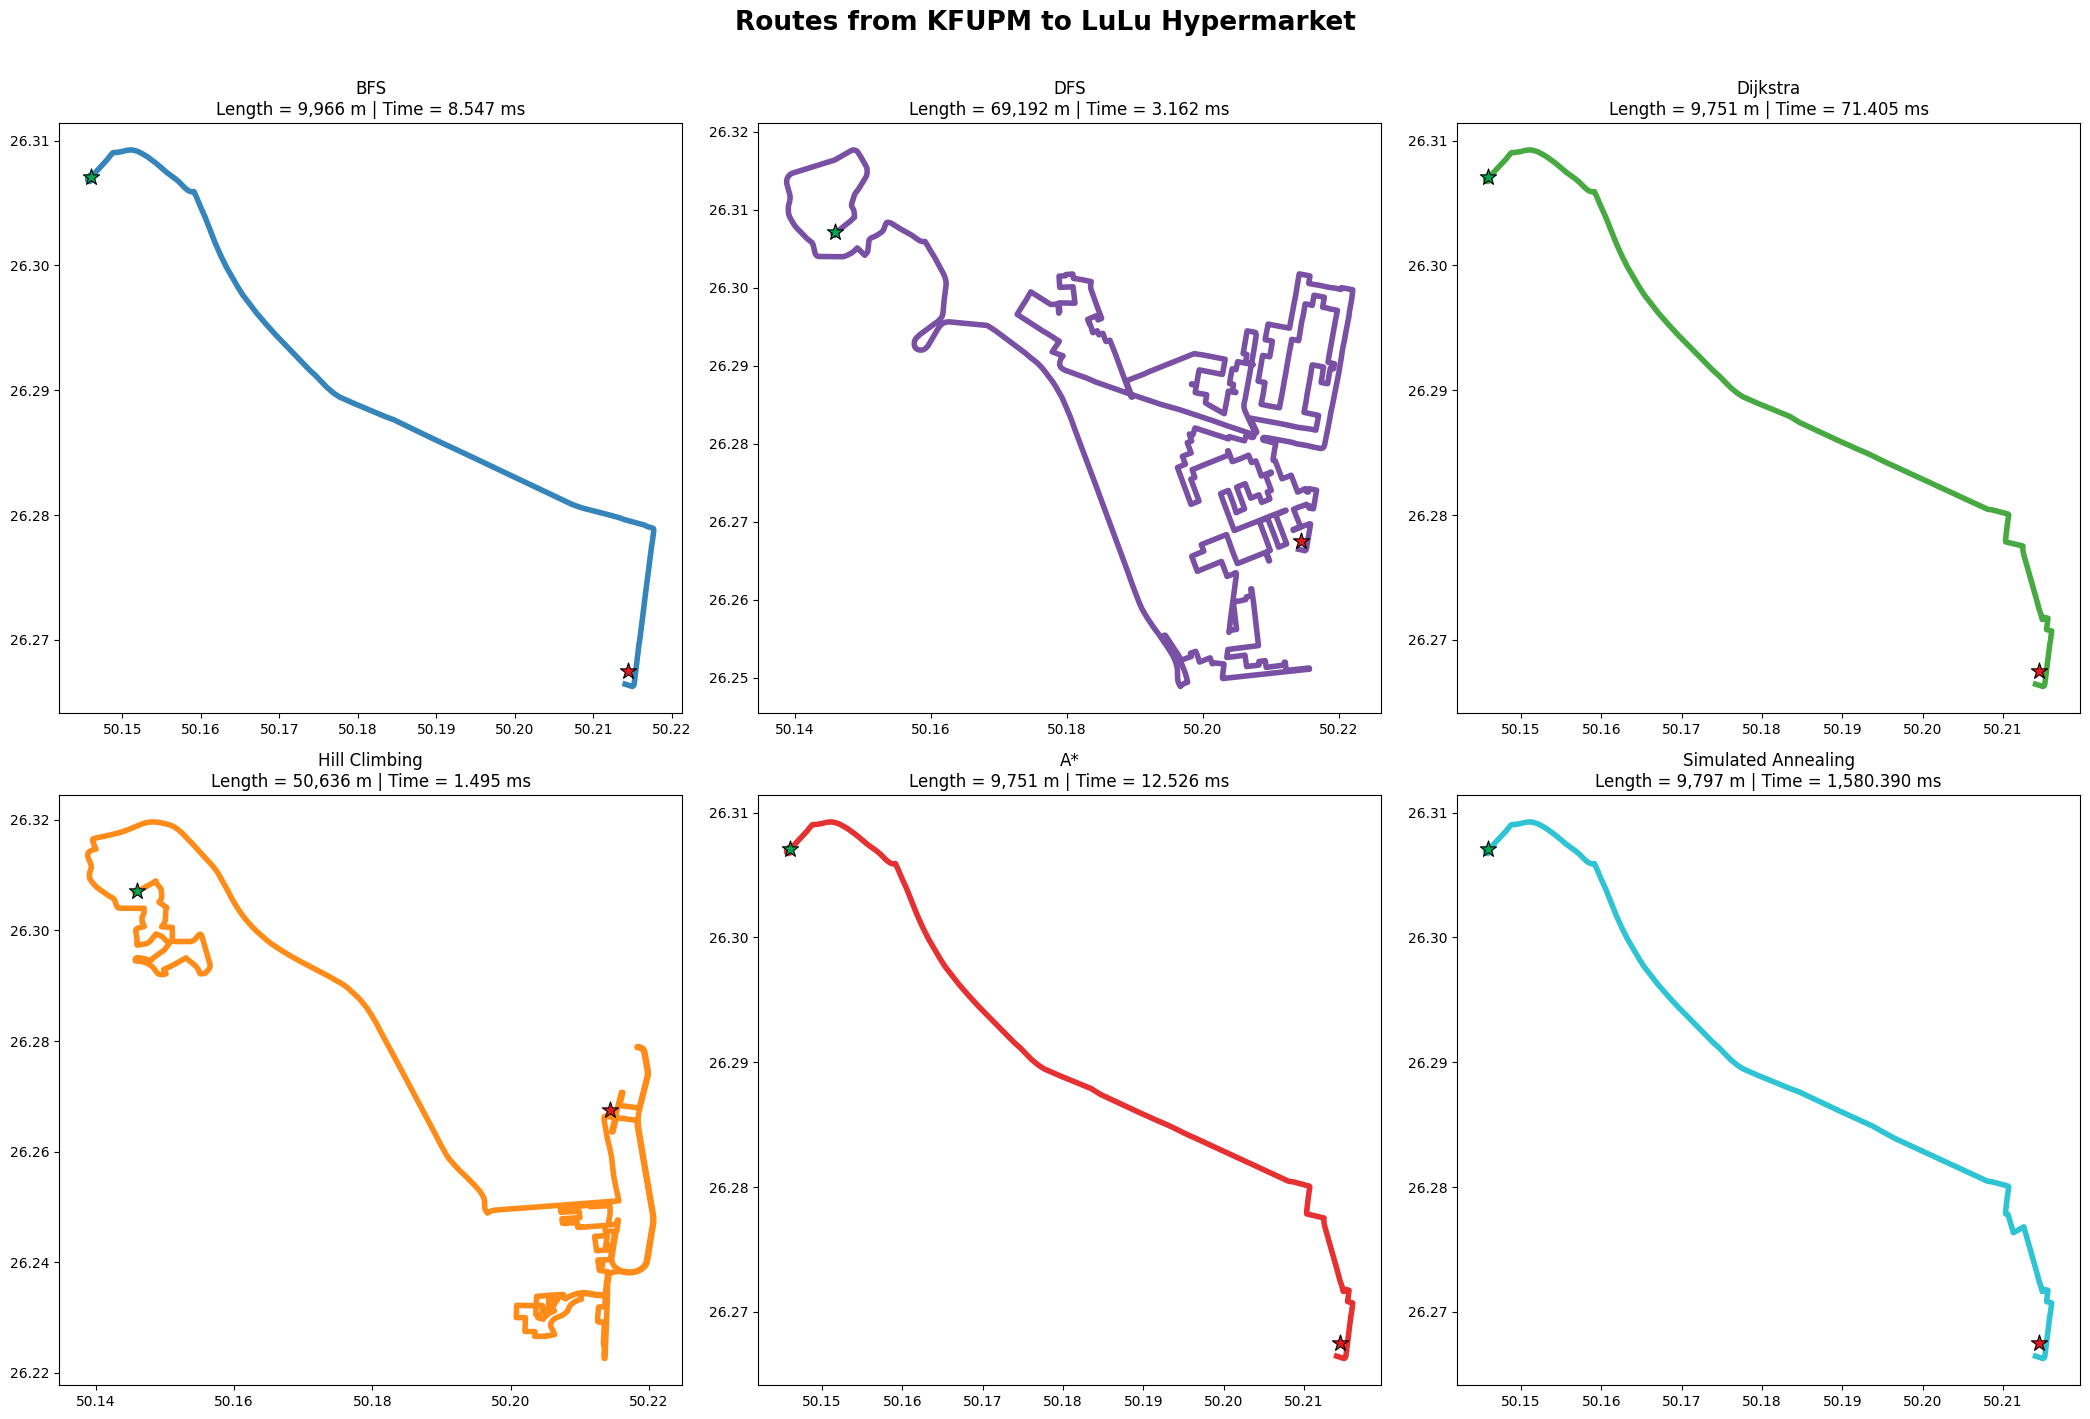

In [35]:
route_colors = {
    "BFS": "#1F78B4",
    "DFS": "#6A3D9A",
    "Dijkstra": "#33A02C",
    "Hill Climbing": "#FF7F00",
    "A*": "#E31A1C",
    "Simulated Annealing": "#17BECF"
}

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(21, 14)
)

axes = axes.flatten()

for ax, algorithm_name in zip(
    axes,
    algorithm_functions.keys()
):
    if algorithm_name not in routes:
        ax.text(
            0.5,
            0.5,
            "No route found",
            ha="center",
            va="center",
            transform=ax.transAxes
        )
        ax.set_title(algorithm_name)
        ax.set_axis_off()
        continue

    route = routes[algorithm_name]

    ox.plot.plot_graph_route(
        G,
        route,
        route_color=route_colors[algorithm_name],
        route_linewidth=4,
        route_alpha=0.9,
        orig_dest_size=0,
        ax=ax,
        node_size=0,
        edge_color="#D0D0D0",
        edge_linewidth=0.55,
        bgcolor="white",
        show=False,
        close=False
    )

    # Origin marker
    ax.scatter(
        POIS["KFUPM"]["longitude"],
        POIS["KFUPM"]["latitude"],
        s=150,
        marker="*",
        color="#00A651",
        edgecolor="black",
        linewidth=0.8,
        zorder=5
    )

    # Destination marker
    ax.scatter(
        POIS["LuLu Hypermarket"]["longitude"],
        POIS["LuLu Hypermarket"]["latitude"],
        s=150,
        marker="*",
        color="#E31A1C",
        edgecolor="black",
        linewidth=0.8,
        zorder=5
    )

    row = comparison[
        comparison["Algorithm"] == algorithm_name
    ].iloc[0]

    ax.set_title(
        f"{algorithm_name}\n"
        f"Length = {row['Route length (m)']:,.0f} m | "
        f"Time = {row['Time (ms)']:,.3f} ms",
        fontsize=12
    )

fig.suptitle(
    "Routes from KFUPM to LuLu Hypermarket",
    fontsize=19,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

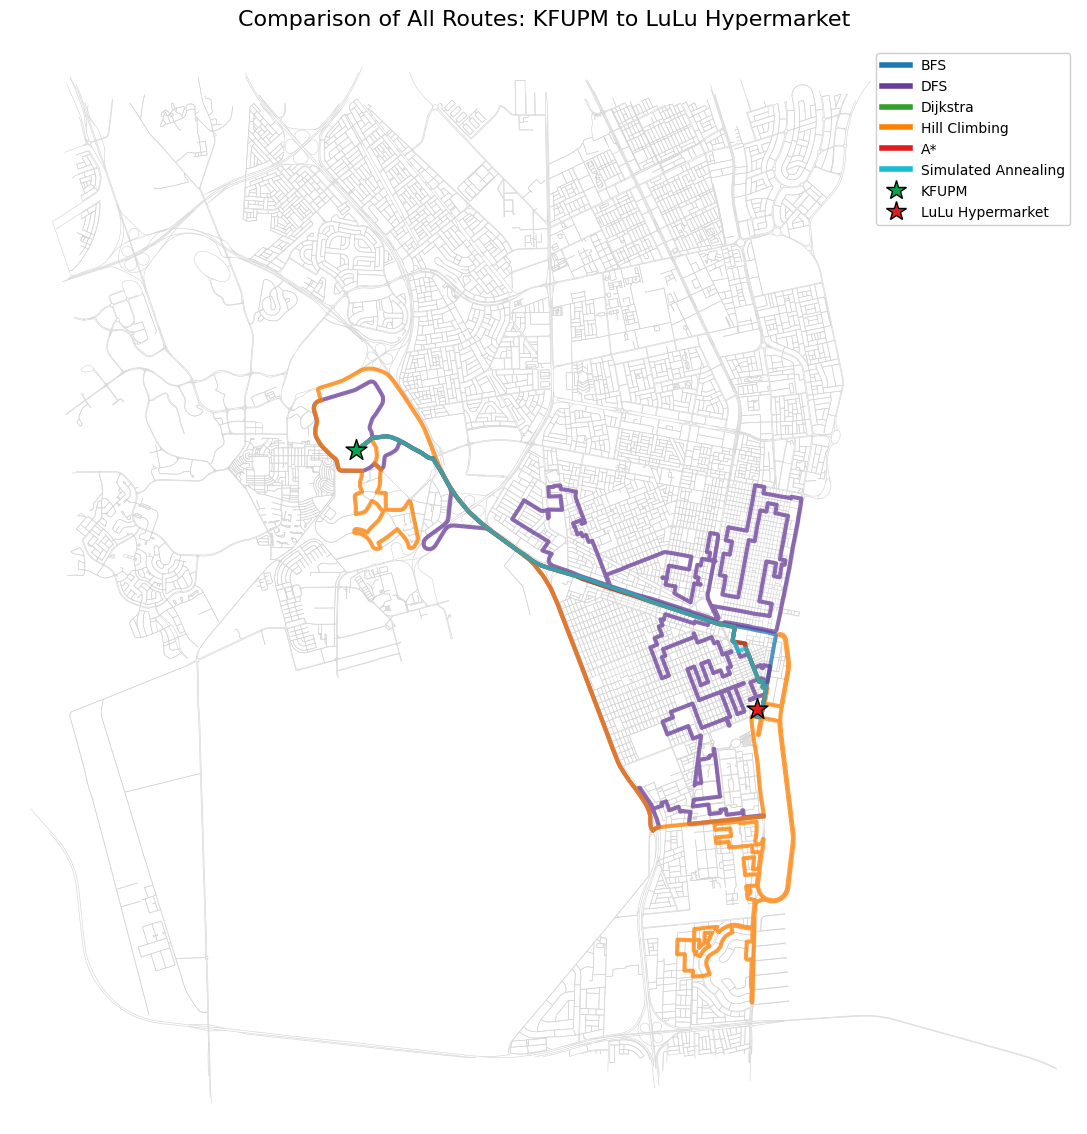

In [36]:
available_algorithms = list(routes.keys())

all_routes = [
    routes[algorithm]
    for algorithm in available_algorithms
]

all_colors = [
    route_colors[algorithm]
    for algorithm in available_algorithms
]

fig, ax = ox.plot.plot_graph_routes(
    G,
    all_routes,
    route_colors=all_colors,
    route_linewidths=[3] * len(all_routes),
    route_alpha=0.75,
    orig_dest_size=0,
    node_size=0,
    edge_color="#D5D5D5",
    edge_linewidth=0.45,
    bgcolor="white",
    show=False,
    close=False,
    figsize=(14, 14)
)

ax.scatter(
    POIS["KFUPM"]["longitude"],
    POIS["KFUPM"]["latitude"],
    s=250,
    marker="*",
    color="#00A651",
    edgecolor="black",
    zorder=10
)

ax.scatter(
    POIS["LuLu Hypermarket"]["longitude"],
    POIS["LuLu Hypermarket"]["latitude"],
    s=250,
    marker="*",
    color="#E31A1C",
    edgecolor="black",
    zorder=10
)

legend_items = [
    Line2D(
        [0],
        [0],
        color=route_colors[algorithm],
        linewidth=4,
        label=algorithm
    )
    for algorithm in available_algorithms
]

legend_items.extend(
    [
        Line2D(
            [0],
            [0],
            marker="*",
            color="white",
            markerfacecolor="#00A651",
            markeredgecolor="black",
            markersize=15,
            label="KFUPM"
        ),
        Line2D(
            [0],
            [0],
            marker="*",
            color="white",
            markerfacecolor="#E31A1C",
            markeredgecolor="black",
            markersize=15,
            label="LuLu Hypermarket"
        )
    ]
)

ax.legend(
    handles=legend_items,
    loc="upper right",
    fontsize=10,
    framealpha=0.95
)

ax.set_title(
    "Comparison of All Routes: KFUPM to LuLu Hypermarket",
    fontsize=16,
    pad=15
)

plt.show()

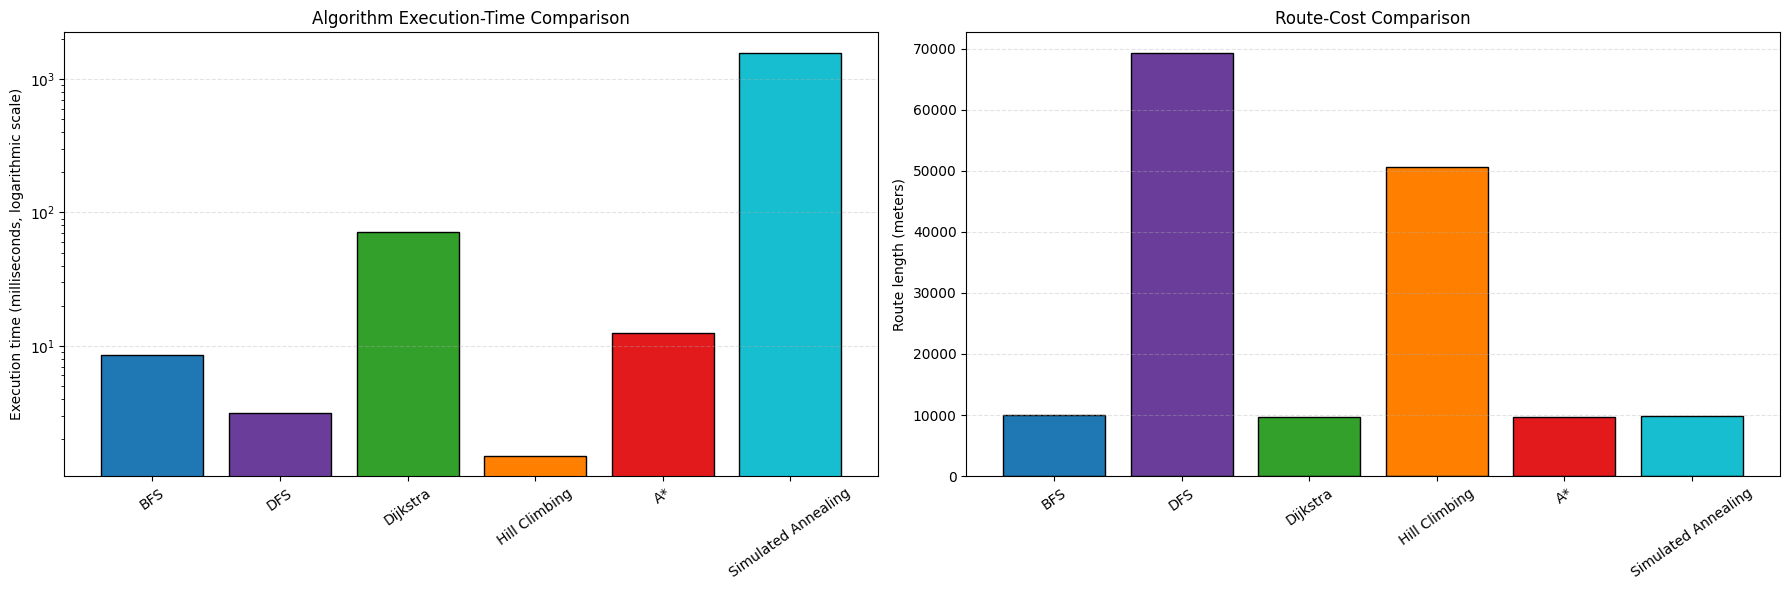

In [37]:
plot_data = comparison[
    comparison["Status"] == "Route found"
].copy()

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 6)
)

colors = [
    route_colors[algorithm]
    for algorithm in plot_data["Algorithm"]
]

# Execution-time comparison
axes[0].bar(
    plot_data["Algorithm"],
    plot_data["Time (ms)"],
    color=colors,
    edgecolor="black"
)

axes[0].set_title("Algorithm Execution-Time Comparison")
axes[0].set_ylabel("Execution time (milliseconds)")
axes[0].tick_params(axis="x", rotation=35)

# Use logarithmic time scale when the algorithms differ greatly.
positive_times = plot_data.loc[
    plot_data["Time (ms)"] > 0,
    "Time (ms)"
]

if (
    len(positive_times) > 1
    and positive_times.max() / positive_times.min() > 100
):
    axes[0].set_yscale("log")
    axes[0].set_ylabel(
        "Execution time (milliseconds, logarithmic scale)"
    )

# Route-length comparison
axes[1].bar(
    plot_data["Algorithm"],
    plot_data["Route length (m)"],
    color=colors,
    edgecolor="black"
)

axes[1].set_title("Route-Cost Comparison")
axes[1].set_ylabel("Route length (meters)")
axes[1].tick_params(axis="x", rotation=35)

for ax in axes:
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.35
    )

plt.tight_layout()
plt.show()

In [38]:
successful_results = comparison[
    comparison["Status"] == "Route found"
].copy()

fastest_result = successful_results.loc[
    successful_results["Time (ms)"].idxmin()
]

shortest_result = successful_results.loc[
    successful_results["Route length (m)"].idxmin()
]

dijkstra_result = successful_results[
    successful_results["Algorithm"] == "Dijkstra"
].iloc[0]

astar_result = successful_results[
    successful_results["Algorithm"] == "A*"
].iloc[0]

display(
    Markdown(
        f"""
## Numerical summary

- The fastest measured algorithm was **{fastest_result['Algorithm']}**,
  with an execution time of approximately
  **{fastest_result['Time (ms)']:.3f} ms**.

- The lowest route cost was produced by
  **{shortest_result['Algorithm']}**, with a route length of approximately
  **{shortest_result['Route length (m)']:,.2f} meters**.

- Dijkstra's route length was
  **{dijkstra_result['Route length (m)']:,.2f} meters**.

- A*'s route length was
  **{astar_result['Route length (m)']:,.2f} meters**.

- The difference between the A* and Dijkstra route costs was
  **{abs(astar_result['Route length (m)'] -
  dijkstra_result['Route length (m)']):,.6f} meters**.
"""
    )
)


## Numerical summary

- The fastest measured algorithm was **Hill Climbing**,
  with an execution time of approximately
  **1.495 ms**.

- The lowest route cost was produced by
  **Dijkstra**, with a route length of approximately
  **9,750.67 meters**.

- Dijkstra's route length was
  **9,750.67 meters**.

- A*'s route length was
  **9,750.67 meters**.

- The difference between the A* and Dijkstra route costs was
  **0.000000 meters**.
